### Evaluate and Plot Resutls

In [1]:
# Imports
import os, sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib as mpl

color_cycle = ['#000000',  # black
               '#E69F00',  # orange
               '#56B4E9',  # light blue
               '#009E73',  # green
               '#F0E442',  # yellow
               '#0072B2',  # blue
               '#D55E00',  # red
               '#CC79A7']  # pink

# Global settings
mpl.rcParams.update({
    # Figure
    'figure.dpi': 300,                                 # figure dots per inch
    'savefig.dpi': 300,                                # save dots per inch
    'figure.figsize': [3.5, 2.5],                      # figure size in inches

    # Axes
    'axes.labelsize': 8,                               # font size of the x and y labels
    'axes.titlesize': 8,                               # font size of the axes title
    'axes.linewidth': 0.6,                             # edge line width
    'xtick.labelsize': 7,                              # font size of the tick labels
    'ytick.labelsize': 7,                              # font size of the tick labels
    'xtick.major.size': 3,                             # major tick size in points
    'ytick.major.size': 3,                             # major tick size in points
    'xtick.direction': 'in',                           # direction: {in, out, inout}
    'ytick.direction': 'in',                           # direction: {in, out, inout}

    # Font
    'font.size': 8,                                    # default font size for text
    'font.family': 'serif',                            # font family
    'font.serif': ['Times New Roman'],                 # font serif ['times new roman']

    # Lines
    'lines.linewidth': 1.0,                            # line width
    'lines.markersize': 4,                             # marker size
    'axes.prop_cycle': mpl.cycler(color=color_cycle),  # color cycler
    
    'grid.linestyle': '--',                            # grid linestyle
    'grid.linewidth': 0.3,                             # grid linewidth
    'grid.alpha': 0.7,                                 # grid transparency 

    # Legend
    'legend.frameon': True,                            # draw with background and frame
    'legend.framealpha': None,                         # legend transparency
    'legend.facecolor': 'white',                       # background color
    'legend.edgecolor': 'black',                       # border color
    'legend.fontsize': 7,                              # legend fontsize
    'legend.borderaxespad': 0.5,                       # the border between the axes and legend edge
    'legend.borderpad': 0.4,                           # border whitespace
    'legend.handlelength': 1.5,                        # the length of the legend lines
    'legend.handletextpad': 0.4,                       # the border between the axes and legend edge
    'legend.labelspacing': 0.3,                        # the vertical space between the legend entries
    'legend.loc': 'best',                              # legend location
})

if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
model_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "src"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
sys.path.append(model_dir)
from data_processing import load_cluster
from yaml_processor import load_config, save_config
from sensor_processing import sensor_processing

from EDM import EDM

config_file = os.path.abspath(os.path.join(script_dir, "..", "configuration.yaml"))
config_global = load_config(config_file)

In [2]:
# Parameters
cluster = 0
chkpnt_path = os.path.join(output_dir, "model_checkpoint", str(cluster))
nx = config_global["data"]["nx"]
nt = config_global["data"]["nt"]
T = 1/np.pi
t = np.linspace(0, T, nt)
dt = t[1]-t[0]

In [3]:
# Set device
device = ('cuda:0' if torch.cuda.is_available() else 'cpu')
# Load Data
FS_train, params_train, ft_train, disp_norm, vel_norm, ft_norm = load_cluster(os.path.join(output_dir, "datasets", "Train"), cluster, normalize=True)
FS_val, params_val, ft_val, _, _, _ = load_cluster(os.path.join(output_dir, "datasets", "Val"), cluster, True, disp_norm, vel_norm, ft_norm)
FS_test, params_test, ft_test, _, _, _ = load_cluster(os.path.join(output_dir, "datasets", "Test"), cluster, True, disp_norm, vel_norm, ft_norm)

In [4]:
# Apply Sensor Placement
sp = sensor_processing(FS_train[:, 1], config_global)
A_Mat, C_Mat, pinv_Theta, sensor_placement = sp.load(output_dir)
RS_train, RS_val, RS_test = sp.apply_sensors(FS_train, FS_val, FS_test)

# Reshape
n_dim = RS_train.shape[1]
RS_train = np.concatenate([RS_train[:, i, :, :] for i in range(n_dim)], axis=-1)
RS_val = np.concatenate([RS_val[:, i, :, :] for i in range(n_dim)], axis=-1)
RS_test = np.concatenate([RS_test[:, i, :, :] for i in range(n_dim)], axis=-1)

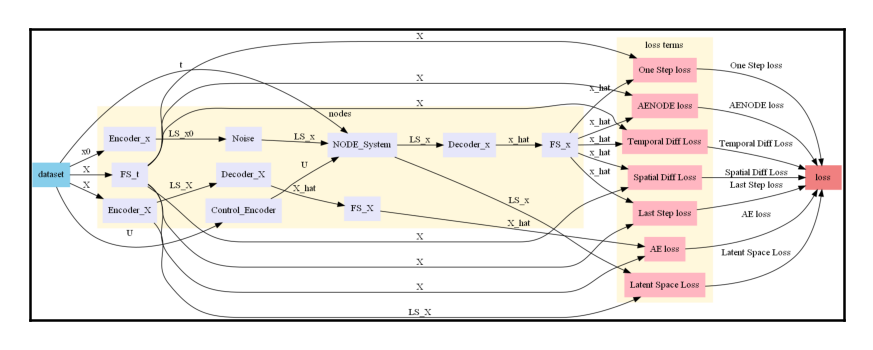

In [5]:
model = EDM(A_Mat, pinv_Theta, dt, config_global, device)
model.build_model()

In [6]:
# Load model
model_params = os.path.abspath(os.path.join(output_dir, "model_checkpoint", str(cluster))) + "/best_model_state_dict.pth"
model.problem.load_state_dict(torch.load(model_params, map_location=torch.device(device)))

<All keys matched successfully>

In [9]:
model.problem.nodes[4].nsteps = nt
model.problem.eval()

### MODEL SUMMARY ###

NODES:
  Encoder_x(x0) -> LS_x0
  Encoder_X(X) -> LS_X
  Noise(LS_x0) -> LS_x
  Control_Encoder(U) -> U
  System(
  (nodes): ModuleList(
    (0): NODE(LS_x, U, t) -> LS_x
  )
)
  Decoder_x(LS_x) -> x_hat
  Decoder_X(LS_X) -> X_hat
  FS_x(x_hat) -> x_hat
  FS_X(X_hat) -> X_hat
  FS_t(X) -> X

CONSTRAINTS: none

OBJECTIVES:
  Constraint(
  (left): slice
  (right): X
  (comparator): Eq()
)
  Constraint(
  (left): X_hat
  (right): X
  (comparator): Eq()
)
  Constraint(
  (left): slice
  (right): slice
  (comparator): Eq()
)
  Constraint(
  (left): slice
  (right): slice
  (comparator): Eq()
)
  Constraint(
  (left): LS_X
  (right): slice
  (comparator): Eq()
)
  Constraint(
  (left): -
  (right): -
  (comparator): Eq()
)
  Constraint(
  (left): +
  (right): +
  (comparator): Eq()
)

In [10]:
_, _, test_data = model.get_data(RS_train, ft_train, RS_val, ft_val, RS_test, ft_test, t[:, np.newaxis])
outputs = model.problem.step(test_data)

In [11]:
t_max = 1/torch.pi
t_torch = torch.tensor(t[:, np.newaxis])
centers = torch.tensor([0.2, 0.5, 0.8]).to(device)
#centers += t_max
t_norm = (t_torch / t_max).clamp(0.0, 1.0)
diff    = (t_norm - centers).abs()
weights = torch.softmax(- (diff**2) / (2 * 0.02**2), dim=1)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

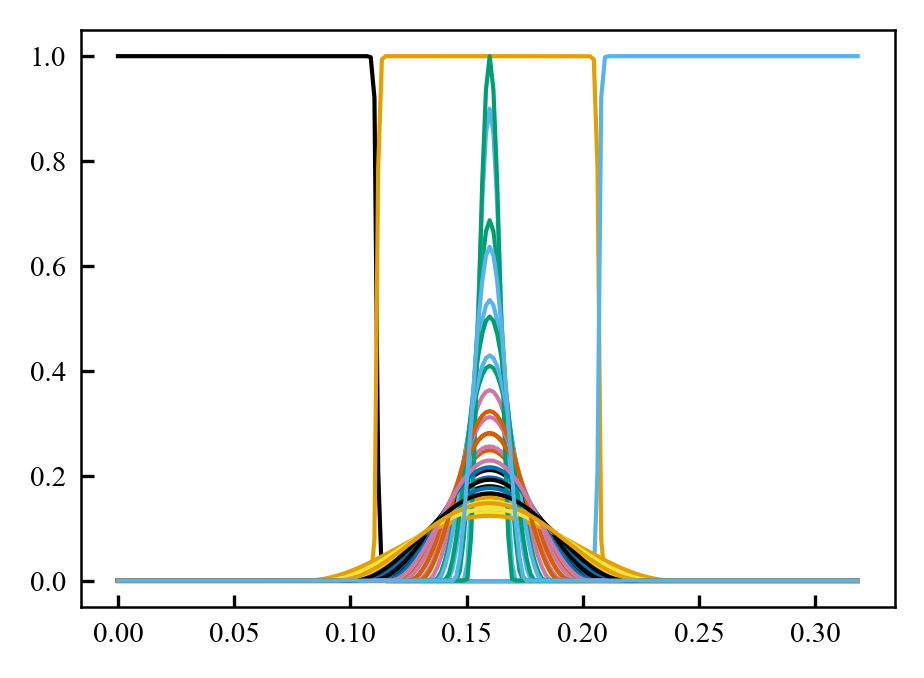

In [28]:
plt.figure()
plt.plot(t, weights)
plt.plot(t, ft_train[:,:,0].T)
plt.show()

In [12]:
FS_reshaped = FS_test.transpose(0, 2, 1, 3).reshape(128, 200, 202)
FS_AE = outputs['X_hat'][:, :, :].cpu().detach().numpy()
FS_pred = outputs['x_hat'][:, :-1, :].cpu().detach().numpy()

In [13]:
print(f"Frob norm for AE is : {np.linalg.norm(FS_AE-FS_reshaped)/np.linalg.norm(FS_reshaped)}")
print(f"Frob norm for NODE is : {np.linalg.norm(FS_pred-FS_reshaped)/np.linalg.norm(FS_reshaped)}")

Frob norm for AE is : 0.024457379648771677
Frob norm for NODE is : 0.07352269210725695


## Params and Sensors

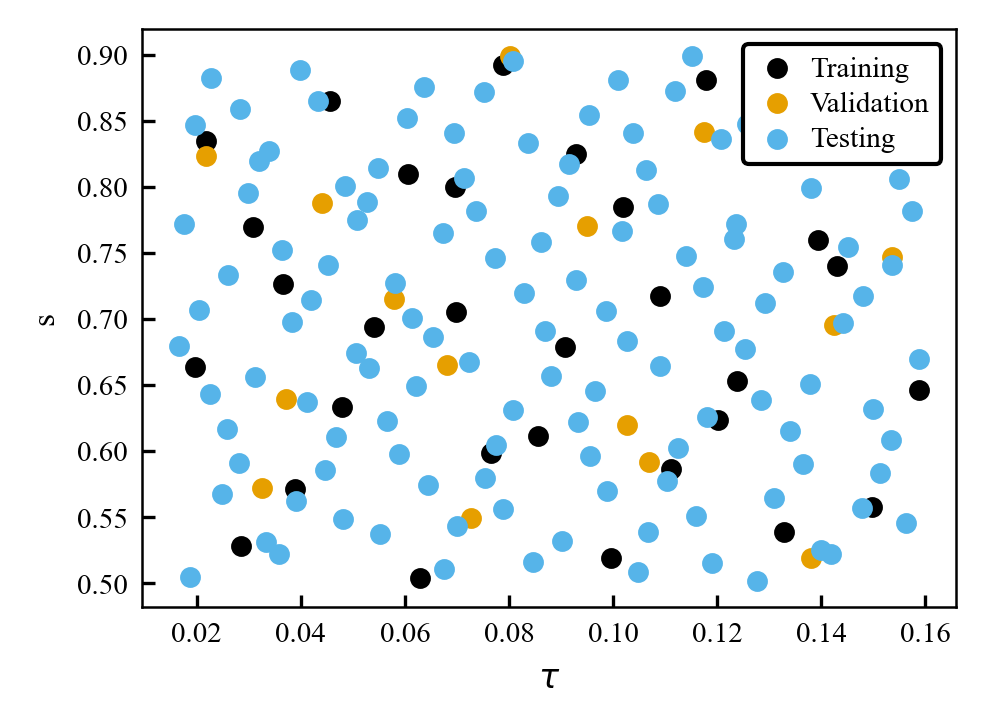

In [92]:
# Params scatter
plt.figure()
plt.tight_layout()
plt.scatter(params_train[:, 0], params_train[:, 1], label="Training")
plt.scatter(params_val[:, 0], params_val[:, 1], label="Validation")
plt.scatter(params_test[:, 0], params_test[:, 1], label="Testing")
plt.ylabel(r"s")
plt.xlabel(r"$\tau$")
plt.legend(loc="upper right")
plt.show()

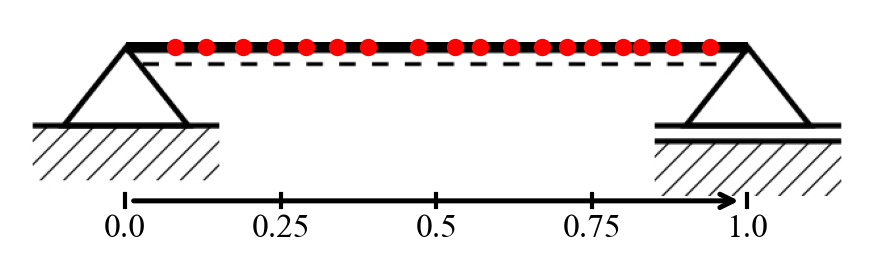

In [158]:
# Sensor Locations
beam = mpimg.imread("supplementary/beam.jpg")
height, width = beam.shape[:2]
xbounds = np.array([72, 545])
xs = (sensor_placement/100)*(xbounds[1]-xbounds[0])+xbounds[0]
ys = np.array([3]*len(sensor_placement))
plt.imshow(beam)
plt.scatter(xs, ys, c='red', s=10, marker='o')  # Customize as needed
plt.axis('off')

x0, y0 = xbounds[0], 120
x_axis_len = xbounds[1]-xbounds[0]
plt.annotate('', xy=(x0 + x_axis_len, y0), xytext=(x0, y0),
            arrowprops=dict(arrowstyle='->', color='black', linewidth=1.2))
xticks = np.linspace(0, 100, 5)
for val in xticks:
    x_tick_pos = x0 + val / 100 * x_axis_len
    plt.plot([x_tick_pos, x_tick_pos], [y0 - 5, y0 + 5], color='black', linewidth=1)
    plt.text(x_tick_pos, y0 + 10, f'{float(val/100)}', ha='center', va='top', fontsize=8)
plt.ylim(height+10, -10)
plt.show()

In [185]:
# Gates Plots
model.problem.nodes[3].callable()

System(
  (nodes): ModuleList(
    (0): NODE(LS_x, U, t) -> LS_x
  )
)

## Results Plots

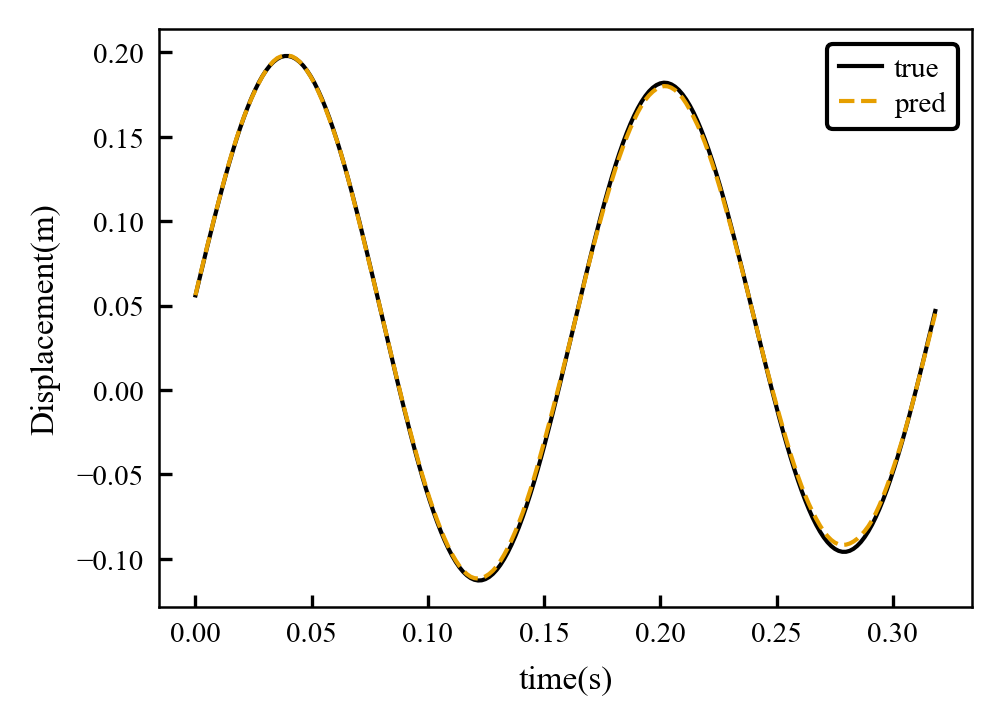

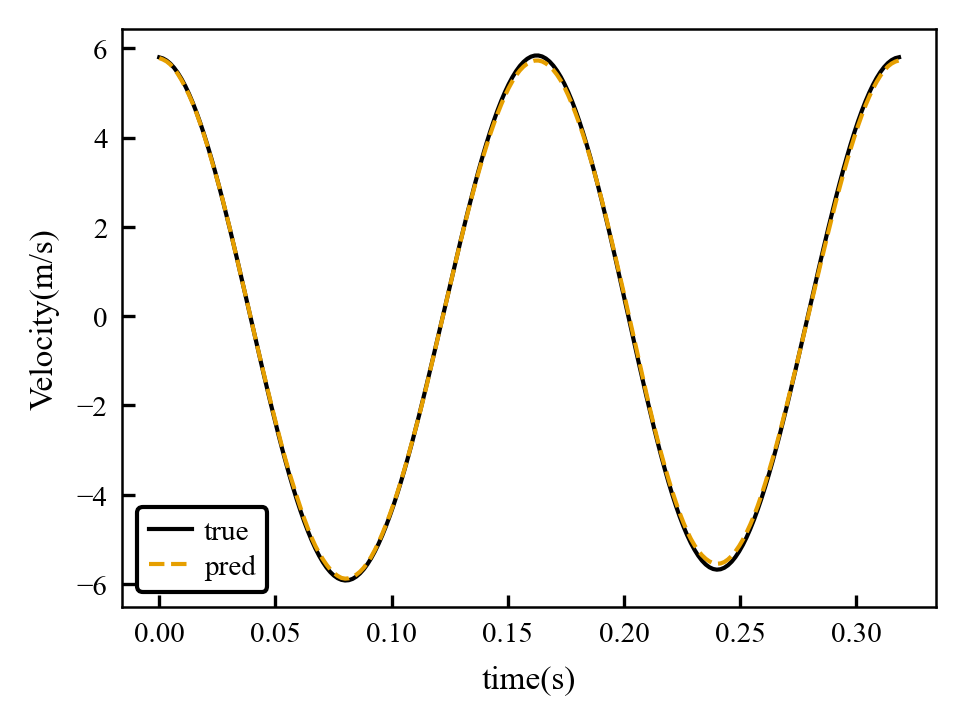

In [180]:
# Single cycle timeline plot
p = 0
x = 75
# Displacement
plt.figure()
plt.tight_layout()
plt.plot(t, FS_reshaped[p, :, x]*disp_norm, label="true")
plt.plot(t, FS_pred[p, :, x]*disp_norm, '--', label="pred")

plt.ylabel("Displacement(m)")
plt.xlabel("time(s)")
plt.legend()
plt.show()

# Velocity
plt.figure()
plt.tight_layout()
plt.plot(t, FS_reshaped[p, :, x+nx]*vel_norm, label="true")
plt.plot(t, FS_pred[p, :, x+nx]*vel_norm, '--', label="pred")

plt.ylabel("Velocity(m/s)")
plt.xlabel("time(s)")
plt.legend()
plt.show()

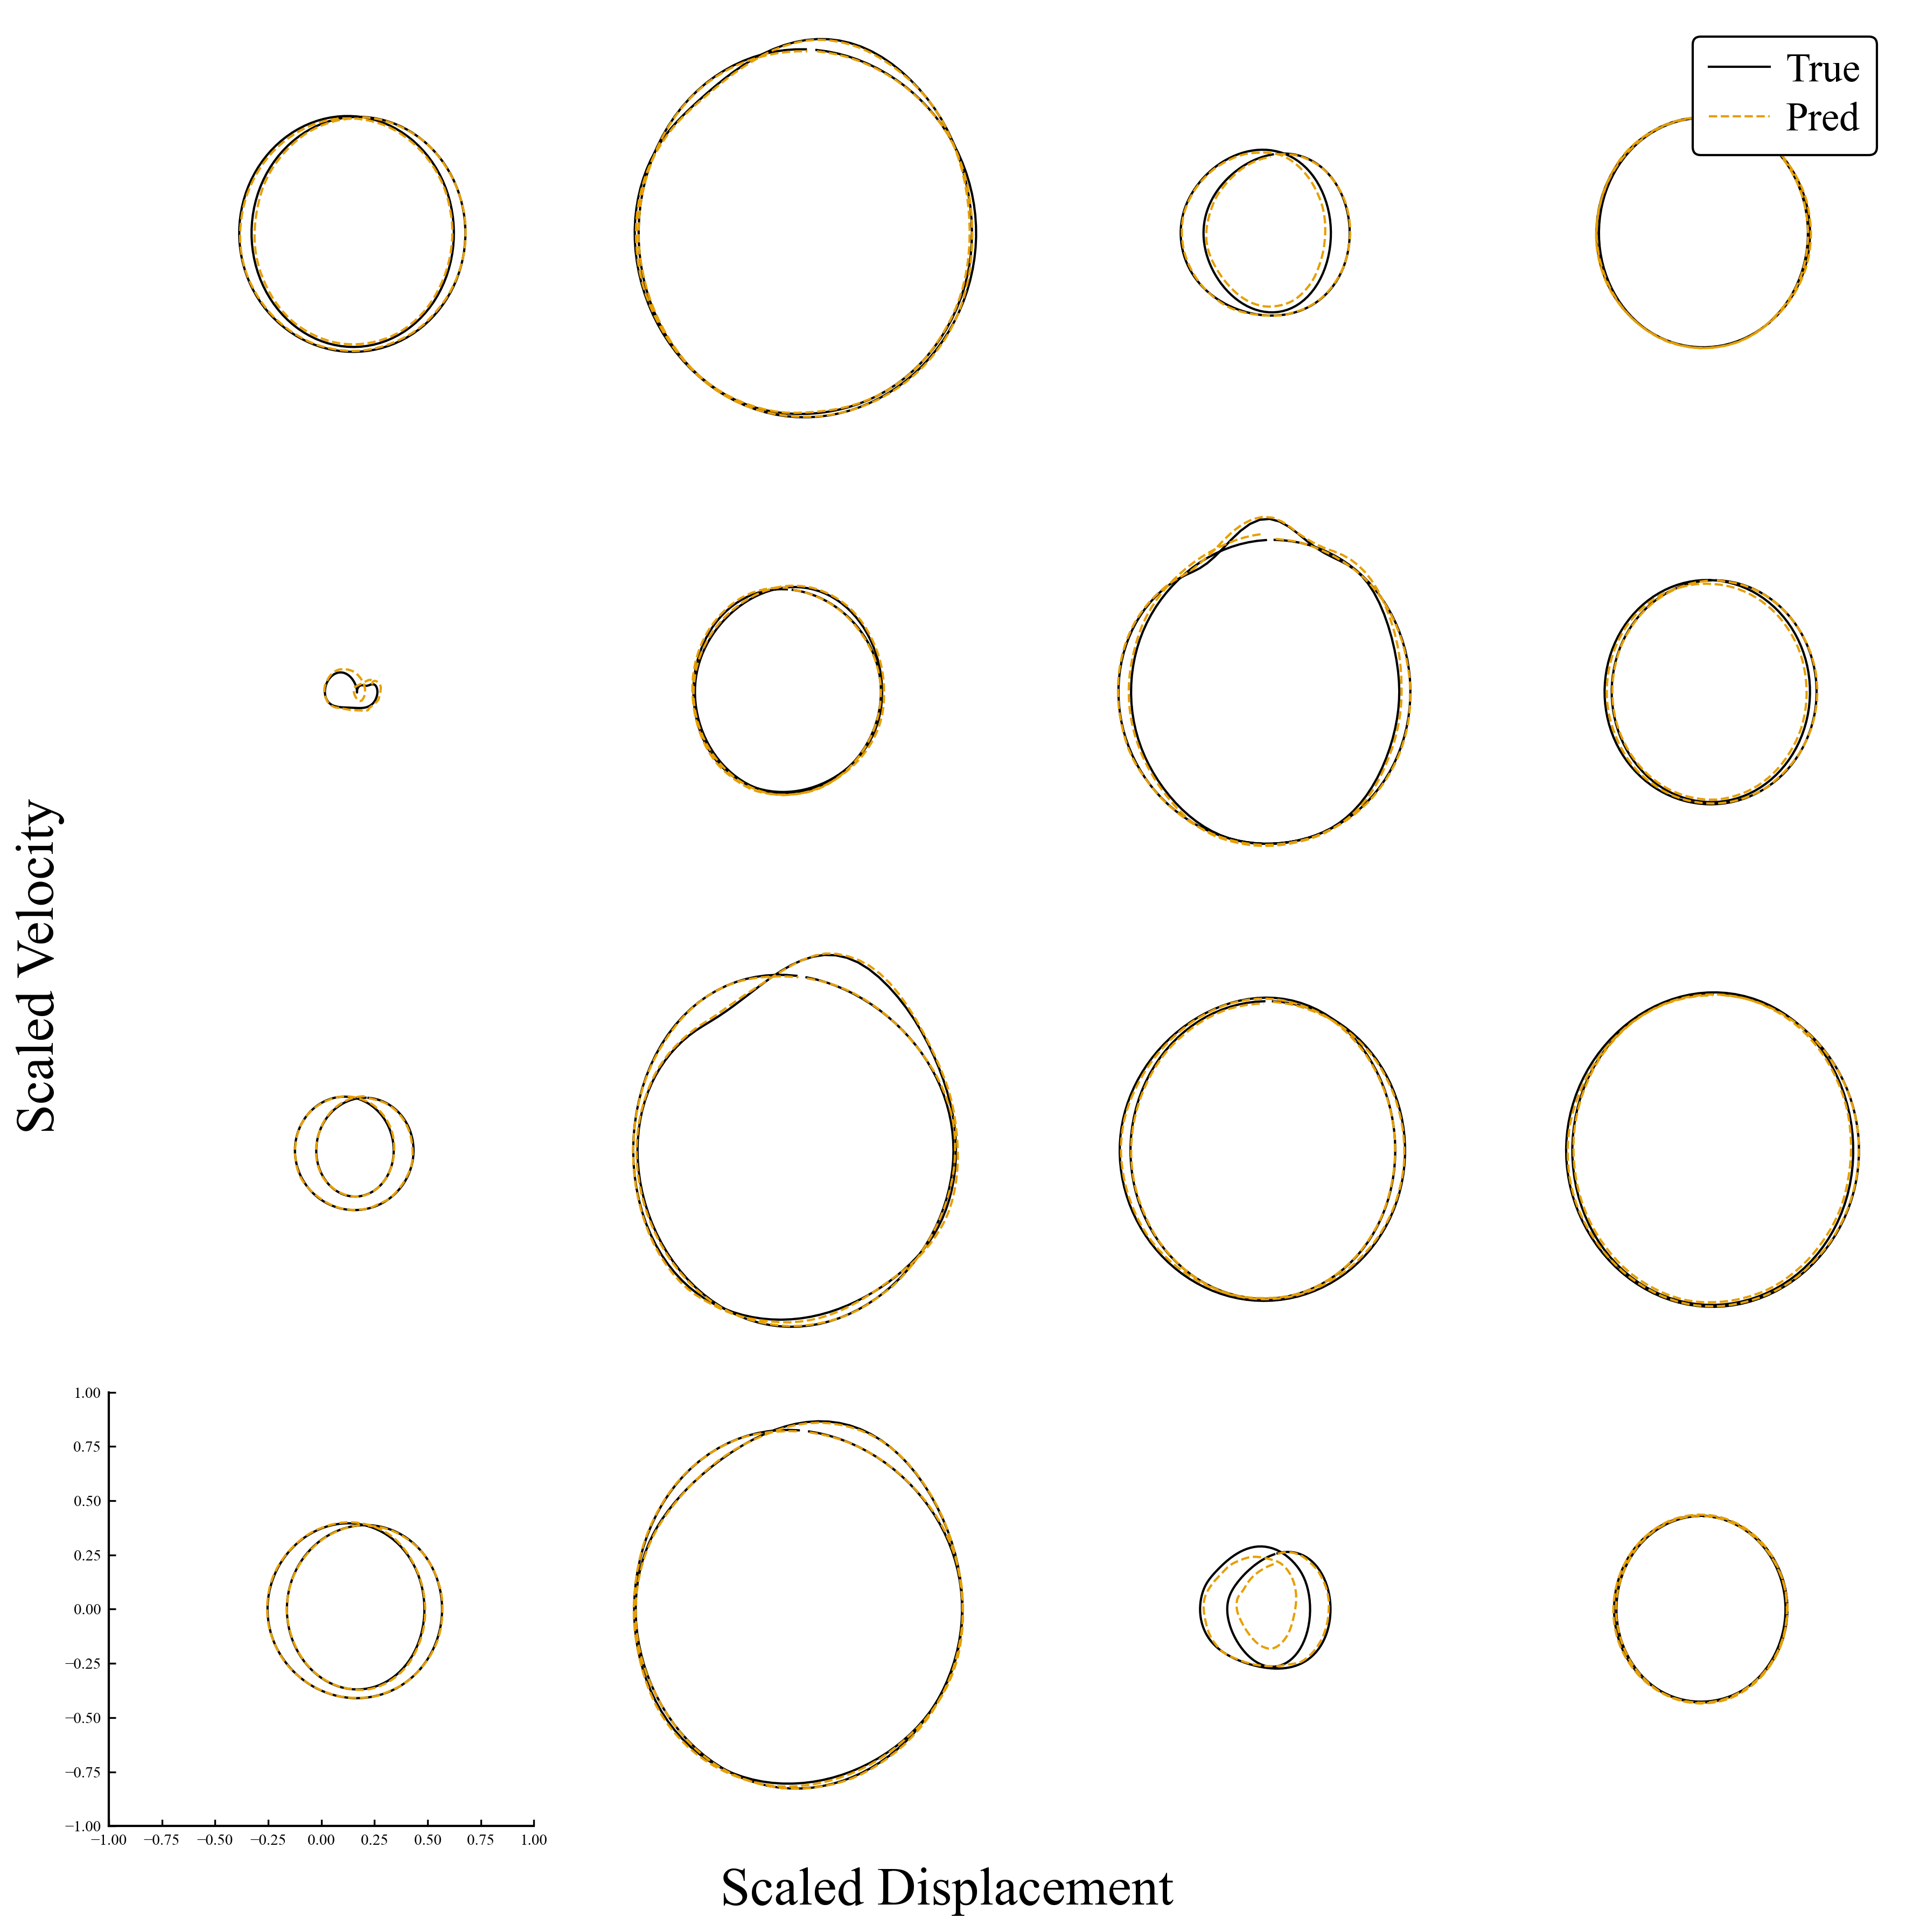

In [177]:
# 4x4 phase plane plots
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
ind = np.linspace(0, 15, 16, dtype=np.int32)
x = 75

it = 0
for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        line1, = ax.plot(FS_reshaped[ind[it], :, x], FS_reshaped[ind[it], :, x+nx], label='True')
        line2, = ax.plot(FS_pred[ind[it], :, x], FS_pred[ind[it], :, x+nx], '--', label='Pred')

        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)

        # Remove all ticks and labels
        ax.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)

        # Remove spines (borders)
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Only show axis on bottom-left plot
        if i == 3 and j == 0:
            ax.tick_params(labelbottom=True, labelleft=True, bottom=True, left=True)

            # Enable only left and bottom spines
            ax.spines['left'].set_visible(True)
            ax.spines['bottom'].set_visible(True)
            ax.spines['left'].set_linewidth(1)
            ax.spines['bottom'].set_linewidth(1)

            # Ensure the other two remain hidden
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

        # Add legend only on top-right plot
        if i == 0 and j == 3:
            ax.legend(handles=[line1, line2], loc='upper right', fontsize=18)

        it += 1

fig.supxlabel('Scaled Displacement', fontsize=24)
fig.supylabel('Scaled Velocity', fontsize=24)
plt.tight_layout()
plt.show()

## Longer Predictions

In [ ]:
num_cycles = 12
model.problem.nodes[3].nsteps = nt*num_cycles
model.problem.eval()